C:\Users\panda\AppData\Local\Temp\ipykernel_17396\2852672621.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['variety'] = filtered_df['variety'].map(label_mapping)


[-0.54 -0.34] -0.1
[-0.54 -0.34] -0.1
[-0.54 -0.34] -0.1
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[ 0.04 -0.07] 0.0
[-0.41 -0.3 ] -0.1
[ 0.08 -0.05] 0.0
[ 0.08 -0.05] 0.0
[ 0.08 -0.05] 0.0
[-0.38 -0.37] -0.1
[-0.38 -0.37] -0.1
[-0.38 -0.37] -0.1
[ 0.23 -0.07] 0.0
[-0.26 -0.38] -0.1
[-0.26 -0.38] -0.1
[-0.26 -0.38] -0.1
[-0.26 -0.38] -0.1
[ 0.42 -0.06] 0.0
[-0.01 -0.36] -0.1
[-0.01 -0.36] -0.1
[-0.01 -0.36] -0.1
[ 0.66 -0.06] 0.0
[ 0.19 -0.38] -0.1
[ 0.19 -0.38] -0.1
[ 0.19 -0.38] -0.1
[ 0.19 -0.38] -0.1
[ 0.82 -0.05] 0.0
[ 0.82 -0.05] 0.0
[ 0.32 -0.39] -0.1
[ 0.32 -0.39] -0.1
[-0.22 -0.78] -0.2
[ 0.55 

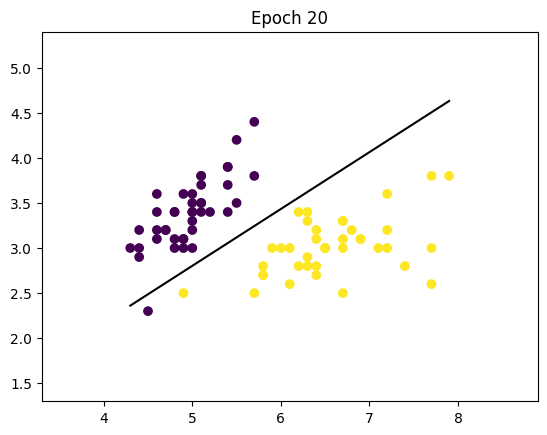

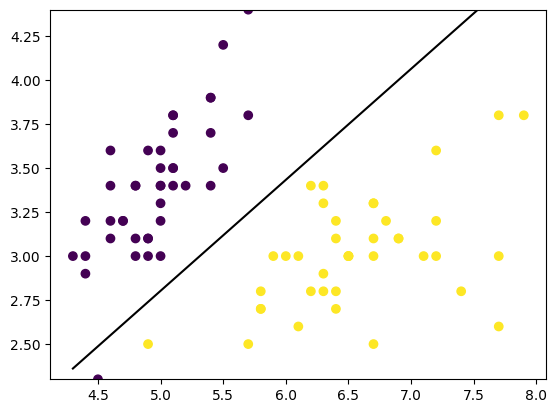

In [13]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.model_selection import train_test_split

def read_data(filename: str) -> pd.DataFrame:
    d = pd.read_csv(filename)
    df = pd.DataFrame(data=d)
    return df

def get_df_shape(df: pd.DataFrame) -> Tuple[int, int]:
    return df.shape

def data_split(
    features: pd.DataFrame, label: pd.Series, test_size: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=test_size)
    return X_train, y_train, X_test, y_test


def extract_features_label(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    # Filter the dataframe to include only Setosa and Virginica rows
    # Extract the required features and labels from the filtered dataframe
    filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    # Map the labels to 0 for Setosa and 1 for Virginica
    label_mapping = {'Setosa': 0, 'Virginica': 1}
    filtered_df['variety'] = filtered_df['variety'].map(label_mapping)

    # Extract the required features (sepal.length and sepal.width) and labels (species)
    features = filtered_df[['sepal.length', 'sepal.width']]
    labels = filtered_df['variety']

    return features, labels

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.activation = self._unit_step_func
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        y_ = np.array([1 if i > 0 else 0 for i in y])
        self.epoch_data = []
        for _ in range(self.epochs):

            for idx, x_i in enumerate(X):

                linear_output = np.dot(x_i, self.weights) + self.bias
                y_hat = self.activation(linear_output)

                update = self.learning_rate * (y_[idx] - y_hat)

                self.weights += update * x_i
                self.bias += update
                print(self.weights, self.bias)
            self.epoch_data.append((self.weights.copy(), self.bias))
        self.create_animation(X,y)
        return self.weights, self.bias

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = self.activation(linear_output)
        return y_predicted

    def _unit_step_func(self, x):
        return np.where(x >= 0, 1, 0)
    
    def create_animation(self, X, y):
        fig, ax = plt.subplots()
        def update(epoch):
            ax.cla()
            ax.scatter(X[:, 0], X[:, 1], marker='o', c=y)

            weights, bias = self.epoch_data[epoch]

            x0_1 = np.amin(X[:, 0])
            x0_2 = np.amax(X[:, 0])
            x1_1 = (-weights[0] * x0_1 - bias) / weights[1]
            x1_2 = (-weights[0] * x0_2 - bias) / weights[1]

            ax.plot([x0_1, x0_2], [x1_1, x1_2], 'k')

            ax.set_xlim(x0_1 - 1, x0_2 + 1)
            ax.set_ylim(np.amin(X[:,1]) - 1, np.amax(X[:,1]) + 1)

            ax.set_title(f"Epoch {epoch + 1}")

        ani = FuncAnimation(fig, update, frames=self.epochs, repeat=False)

        ani.save('perceptron_decision_boundary.gif', writer='pillow', fps=2)

# Testing
if __name__ == "__main__":
    def accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy
    
    df=read_data("iris.csv")
    shape = get_df_shape(df)
    features, label = extract_features_label(df)
    X_train, y_train, X_test, y_test = data_split(features, label, 0.2)
    X_train, y_train, X_test, y_test = X_train.values, y_train.values, X_test.values, y_test.values

    p = Perceptron(learning_rate=0.1, epochs=20)
    p.fit(X_train, y_train)
    predictions = p.predict(X_test)

    print("Perceptron classification accuracy", accuracy(y_test, predictions))

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X_train[:, 0], X_train[:, 1], marker="o", c=y_train)

    x0_1 = np.amin(X_train[:, 0])
    x0_2 = np.amax(X_train[:, 0])

    x1_1 = (-p.weights[0] * x0_1 - p.bias) / p.weights[1]
    x1_2 = (-p.weights[0] * x0_2 - p.bias) / p.weights[1]

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")

    ymin = np.amin(X_train[:, 1])
    ymax = np.amax(X_train[:, 1])
    ax.set_ylim([ymin, ymax])

    plt.show()
